<a href="https://colab.research.google.com/github/michael-sorani/LM4GeoAI/blob/main/Exercises/EX_1_Geo_Semantic_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ex 1: **Geo-Semantic Search**
### created by Etzion Harari | Geo-AI Course

[**https://github.com/EtzionR/LM4GeoAI**](https://github.com/EtzionR/LM4GeoAI)

## Prerequisites: pip install osmnx
[https://osmnx.readthedocs.io/en/stable/](https://osmnx.readthedocs.io/en/stable/)

In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 5.3 MB/s eta 0:00:00


## Imports

In [1]:
from pandas.errors import SettingWithCopyWarning
from shapely import Point, Polygon
from time import time as get_time
from transformers import pipeline
from tqdm import tqdm

import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import osmnx as ox
import numpy as np
import warnings
import folium

## Ignore pandas Warning

In [2]:
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

## Global variables: EPSG codes (define the spatial reference systems)

In [3]:
WGS84_UTM_31N = "EPSG:32631"
WGS84_GEO_DD  = "EPSG:4326"


## Define Food type place_type in OSM data

In [4]:
FOOD = {'restaurant', 'fast_food', 'cafe'}
FOOD

{'cafe', 'fast_food', 'restaurant'}

### Eiffel Tower Location
WGS84 GEO DD X = 2.2944492, Y = 48.8583088

WGS84 GEO UTM 31N X = 448248, Y = 5411944

In [5]:
EIFFEL = Point(448248, 5411944)

## Display Eiffel Tower on the map

In [6]:

eiffecl_wgs84_dd = gpd.GeoSeries([EIFFEL], crs=WGS84_UTM_31N).to_crs(WGS84_GEO_DD).iloc[0]

eiffel_x, eiffel_y = eiffecl_wgs84_dd.x, eiffecl_wgs84_dd.y

fmap = folium.Map(location=[eiffel_y,eiffel_x], zoom_start=15, width=1500, height=500)
folium.Marker([eiffel_y,eiffel_x], popup="Tour Eiffel", tooltip="Tour Eiffel").add_to(fmap)
fmap

## OSM search parameters

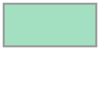

In [7]:
tags = {"amenity": True}

Paris = Polygon([(2.274507, 48.872479),
                 (2.351680, 48.872479),
                 (2.351680, 48.836947),
                 (2.274507, 48.836947),
                 (2.274507, 48.872479)])

Paris

## Load Data from OSM

In [8]:
START = get_time()

pois = ox.features_from_polygon(Paris, tags)

END = get_time()


print(f'Time to extarct data from OSM: {round(END-START,1)} seconds ({round((END-START)/60,1)} minutes)\n\n')

Time to extarct data from OSM: 12.8 seconds (0.2 minutes)




## Preprocess OSM data

In [9]:
pois = pois[['name', 'amenity', 'geometry']].dropna().rename(columns={'amenity':'place_type'}).to_crs(WGS84_UTM_31N)
pois['IsFood'] = pois.place_type.apply(lambda value: value in FOOD)

pois.head()

name      place_type  \
element id                                                  
node    21662099               Notre-Dame  ferry_terminal   
        29434739    Paris École Militaire     post_office   
        207782744           Paris Sentier     post_office   
        218117881  Parking Hôtel de Ville         parking   
        241110355  Bibliothèque Vaugirard         library   

                                         geometry  IsFood  
element id                                                 
node    21662099   POINT (452320.712 5411188.723)   False  
        29434739   POINT (449155.089 5411637.554)   False  
        207782744  POINT (452027.373 5412910.533)   False  
        218117881  POINT (452300.497 5411757.428)   False  
        241110355  POINT (448589.838 5410098.839)   False

# --------------------------------------------------------------------

## Q1

#### Display the ratio of food type POIs (using "IsFood" column)

In [11]:
is_food_ratio = pois['IsFood'].value_counts(normalize=True)
is_food_ratio

,proportion
IsFood,
True,0.566988
False,0.433012


## Q2

#### Display the 10 most frequent **place_type**s

In [12]:
pois['place_type'].value_counts()[:10]

,count
place_type,
restaurant,3019
cafe,874
fast_food,813
bar,546
bank,301
bicycle_rental,283
school,282
pharmacy,236
place_of_worship,118


In [14]:
pois.loc[pois['IsFood'], 'place_type'].value_counts()[:10]

,count
place_type,
restaurant,3019
cafe,874
fast_food,813


## Q3

#### Calculate the distance (in meters) between each POI to Eiffel Tower

In [16]:
pois['distance_from_eiffel'] = pois['geometry'].distance(EIFFEL)
print(pois['distance_from_eiffel'].describe())
pois[['name', 'place_type', 'distance_from_eiffel']].head()

count    8300.000000
mean     2781.036206
std      1111.499794
min        10.872478
25%      1845.586534
50%      2962.028086
75%      3761.092263
max      4799.218606
Name: distance_from_eiffel, dtype: float64


name      place_type  \
element id                                                  
node    21662099               Notre-Dame  ferry_terminal   
        29434739    Paris École Militaire     post_office   
        207782744           Paris Sentier     post_office   
        218117881  Parking Hôtel de Ville         parking   
        241110355  Bibliothèque Vaugirard         library   

                   distance_from_eiffel  
element id                               
node    21662099            4142.152038  
        29434739             957.454733  
        207782744           3901.005771  
        218117881           4056.789086  
        241110355           1876.558779

## Q4

#### 1) Select the 100 POIs closest to the Eiffel Tower and construct a new DataFrame containing only these POIs.

#### 2) Calculate the maximum distance (in meters) from the Eiffel Tower among the POIs in the selected DataFrame

In [17]:
eiffel_closest_pois = pois.sort_values('distance_from_eiffel').head(100)

max_eiffel_dist = eiffel_closest_pois['distance_from_eiffel'].max()
max_eiffel_dist

503.5064742719538

## Q5

#### Display the ratio of food type POIs, only for the 100 closest entities to Eiffel Tower (using "IsFood" column)

In [18]:
eiffel_closest_is_food_ratio = eiffel_closest_pois['IsFood'].value_counts(normalize=True)
eiffel_closest_is_food_ratio

,proportion
IsFood,
True,0.57
False,0.43


## Q6

#### Display the 100 closest entities to Eiffel Tower, using folium

In [23]:
eiffel_closest_map = folium.Map(location=[eiffel_y, eiffel_x], zoom_start=15, width=1500, height=800)

for idx, row in eiffel_closest_pois.iterrows():
    # Convert UTM geometry to WGS84 lat/lon for Folium
    poi_wgs84 = gpd.GeoSeries([row['geometry']], crs=WGS84_UTM_31N).to_crs(WGS84_GEO_DD).iloc[0]
    # Use centroid for both Point and Polygon geometries
    lat, lon = poi_wgs84.centroid.y, poi_wgs84.centroid.x
    name = row['name']
    folium.Marker([lat, lon], popup=name, tooltip=name).add_to(eiffel_closest_map)

eiffel_closest_map

## Q7

#### 1) Load the [multilingual-e5](https://huggingface.co/intfloat/multilingual-e5-large) language model using the **pipeline** interface for the **feature-extraction** task.

#### 2) Implement a function that takes a text string as input and returns a **single** embedding vector representing the text.

#### 3) Apply the function to a sample text and demonstrate the resulting embedding.



In [24]:
from transformers import pipeline, AutoTokenizer
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np

In [25]:
MODEL = "intfloat/multilingual-e5-large"
MODEL

'intfloat/multilingual-e5-large'

In [26]:
embedder = pipeline("feature-extraction", model=MODEL)
embedder

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

FeatureExtractionPipeline: {'model': 'XLMRobertaModel', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [47]:
def text_to_one_embedding(text):
  # The embedder returns a list of token embeddings for the input text
  # We take the first element (assuming a single text input)
  token_embeddings = embedder(text)[0]
  # Compute the max of the token embeddings to get a single sentence embedding
  sentence_embedding = np.max(token_embeddings, axis=0)
  return sentence_embedding

In [48]:
from torch import cos_
example_1 = 'I want to eat an ice-cream'
exemple_2 = 'The pizza in Paris is not tasty'
example_3 = 'Albert Einstein was born in Ulm, Germany'

emb_1 = text_to_one_embedding(example_1)
emb_2 = text_to_one_embedding(exemple_2)
emb_3 = text_to_one_embedding(example_3)

cos_sim_1_2 = np.dot(emb_1, emb_2) / (np.linalg.norm(emb_1) * np.linalg.norm(emb_2))
cos_sim_1_3 = np.dot(emb_1, emb_3) / (np.linalg.norm(emb_1) * np.linalg.norm(emb_3))
cos_sim_2_3 = np.dot(emb_2, emb_3) / (np.linalg.norm(emb_2) * np.linalg.norm(emb_3))
print(f'cos_sim_1_2: {round(cos_sim_1_2, 4)}')
print(f'cos_sim_1_3: {round(cos_sim_1_3, 4)}')
print(f'cos_sim_2_3: {round(cos_sim_2_3, 4)}')

cos_sim_1_2: 0.7972
cos_sim_1_3: 0.7723
cos_sim_2_3: 0.7781


## Q8

#### Compute a text embedding for each place name (from the name column) corresponding to of the 100 closest entities to the Eiffel Tower (use the function from Q7.2).

In [49]:
eiffel_closest_pois['embedding'] = eiffel_closest_pois['name'].apply(text_to_one_embedding)
eiffel_closest_pois.head()

name   place_type  \
element id                                             
way     308145239      Madame Brasserie   restaurant   
node    13665571861    Madame Brasserie    fast_food   
        3135278479       Le Jules Verne   restaurant   
        13665558530  Snacks et boissons    fast_food   
        3134285384    Paris Tour Eiffel  post_office   

                                                              geometry  \
element id                                                               
way     308145239    POLYGON ((448230.704 5411941.956, 448220.425 5...   
node    13665571861                     POINT (448257.603 5411960.205)   
        3135278479                       POINT (448251.491 5411925.21)   
        13665558530                     POINT (448266.877 5411954.072)   
        3134285384                      POINT (448251.664 5411906.687)   

                     IsFood  distance_from_eiffel  \
element id                                          
way     308145239      True             10.872478   
node    13665571861    True             18.837171   
        3135278479     True             19.111780   
        13665558530    True             21.396102   
        3134285384    False             37.492368   

                                                             embedding  
element id                                                              
way     308145239    [1.5537179708480835, 0.3098219931125641, 0.194...  
node    13665571861  [1.5537179708480835, 0.3098219931125641, 0.194...  
        3135278479   [-0.6150420308113098, 0.5099128484725952, 0.22...  
        13665558530  [0.7163798213005066, 0.92166668176651, 0.56615...  
        3134285384   [0.9651191830635071, 0.47746461629867554, 0.40...

## Q9

#### Using the function defined in Q7.2, compute the text embedding for the following free-text input:

``` sh
QUERY = "I want something to eat"

```

In [51]:
embedded_query = text_to_one_embedding('I want something to eat')
embedded_query

array([ 1.1345377 ,  0.15420584,  0.0966409 , ..., -0.47923836,
       -0.61367005,  0.19144896])

## Q10

#### 1) Compute the distance between the query embedding and each place-name embedding using the **L1 norm**.

#### 2) Compute the distance between the query embedding and each place-name embedding using the **L2 norm**.

#### 3) Compute the distance between the query embedding and each place-name embedding using **cosine similarity** based distance.

#### 4) As a baseline metric, generate a random value $r \sim U[0,1]$ for each place name.

# ------

## Additional details on the distance matrices are provided below:

$x$ - Embedding vector of given 100 POI place name

$q$ - Embedding vector of the input Query

$x,q \in \mathbb{R}^{n}$


distance functions:

 - L1 (Manhattan Distance): $L1(x, q) = \frac{1}{n}\sum_{i=1}^{n}|x_i-q_i|$
 - L2 (Euclidean Distance): $L2(x, q) = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i-q_i)^{2}}$
 - CS (Cosine Similarity): $CS(x, q) = \frac{x^{t}q}{||x|| \cdot ||q||} = \frac{\sum_{i=1}^{n}(x_i \cdot q_i)}{\sqrt{\sum_{i=1}^{n}x_i^2} \cdot \sqrt{\sum_{i=1}^{n}q_i^2}} $


##

In [52]:
# 1. L1 norm
eiffel_closest_pois['dist_L1'] = eiffel_closest_pois['embedding'].apply(lambda x: np.linalg.norm(x - embedded_query, ord=1))

# 2. L2 norm
eiffel_closest_pois['dist_L2'] = eiffel_closest_pois['embedding'].apply(lambda x: np.linalg.norm(x - embedded_query, ord=2))

# 3. Cosine
eiffel_closest_pois['dist_CS'] = eiffel_closest_pois['embedding'].apply(lambda x: np.dot(x, embedded_query) / (np.linalg.norm(x) * np.linalg.norm(embedded_query)))

## Q11

#### 1) For each $K \in \{ 5, 10, 25, 50, 100\}$, compute the **Precision@K** for the top-K closest places according to each distance metric (L1, L2, cosine similarity, random baseline, and the naive distance from the Eiffel Tower).

#### 2) Display the output results in as a pandas dataframe table




In [58]:
precision_L1 = []
precision_L2 = []
precision_CS = []
precision_random = []
precision_naive = []

for k in [5, 10, 25, 50, 100]:
  eiffel_closest_pois['rank_L1'] = eiffel_closest_pois['dist_L1'].rank(ascending=True)
  eiffel_closest_pois['rank_L2'] = eiffel_closest_pois['dist_L2'].rank(ascending=True)
  eiffel_closest_pois['rank_CS'] = eiffel_closest_pois['dist_CS'].rank(ascending=True)
  eiffel_closest_pois['rank_random'] = np.random.rand(len(eiffel_closest_pois))
  eiffel_closest_pois['rank_naive'] = eiffel_closest_pois['distance_from_eiffel'].rank(ascending=True)

  precision_L1.append(round((eiffel_closest_pois['rank_L1'] <= k).mean(), 4))
  precision_L2.append(round((eiffel_closest_pois['rank_L2'] <= k).mean(), 4))
  precision_CS.append(round((eiffel_closest_pois['rank_CS'] <= k).mean(), 4))
  precision_random.append(round((eiffel_closest_pois['rank_random'] <= k).mean(), 4))
  precision_naive.append(round((eiffel_closest_pois['rank_naive'] <= k).mean(), 4))


precision_df = pd.DataFrame({
    'K': [5, 10, 25, 50, 100],
    'Precision_L1': precision_L1,
    'Precision_L2': precision_L2,
    'Precision_CS': precision_CS,
    'Precision_random': precision_random,
    'Precision_naive': precision_naive
})
precision_df



,K,Precision_L1,Precision_L2,Precision_CS,Precision_random,Precision_naive
0,5,0.05,0.05,0.05,1.0,0.05
1,10,0.10,0.10,0.10,1.0,0.10
2,25,0.25,0.25,0.25,1.0,0.25
3,50,0.50,0.50,0.50,1.0,0.50
4,100,1.00,1.00,1.00,1.0,1.00


## Q12

#### 1) Compute **Precision@K** for each $K \in \{5,6,7, \cdot \cdot \cdot, 98, 99, 100 \}$ across all distance metrics (L1, L2, cosine similarity, random baseline, and the naive distance from the Eiffel Tower).

#### 2) Create a figure that visualizes **Precision@K** as a function of K for each distance metric.

#### 3) Add to the figure the proportion of food-related places among the 100 closest points of interest to the Eiffel Tower (as computed in Q5).

#### 4) Interpret and explain the results presented in the figure.


   K  Precision_L1  Precision_L2  Precision_CS  Precision_random  \
0  5      1.000000      1.000000      1.000000          0.400000   
1  6      1.000000      1.000000      1.000000          0.500000   
2  7      1.000000      1.000000      1.000000          0.571429   
3  8      0.875000      0.875000      0.875000          0.625000   
4  9      0.888889      0.777778      0.888889          0.666667   

   Precision_naive  
0         0.800000  
1         0.833333  
2         0.714286  
3         0.625000  
4         0.555556  


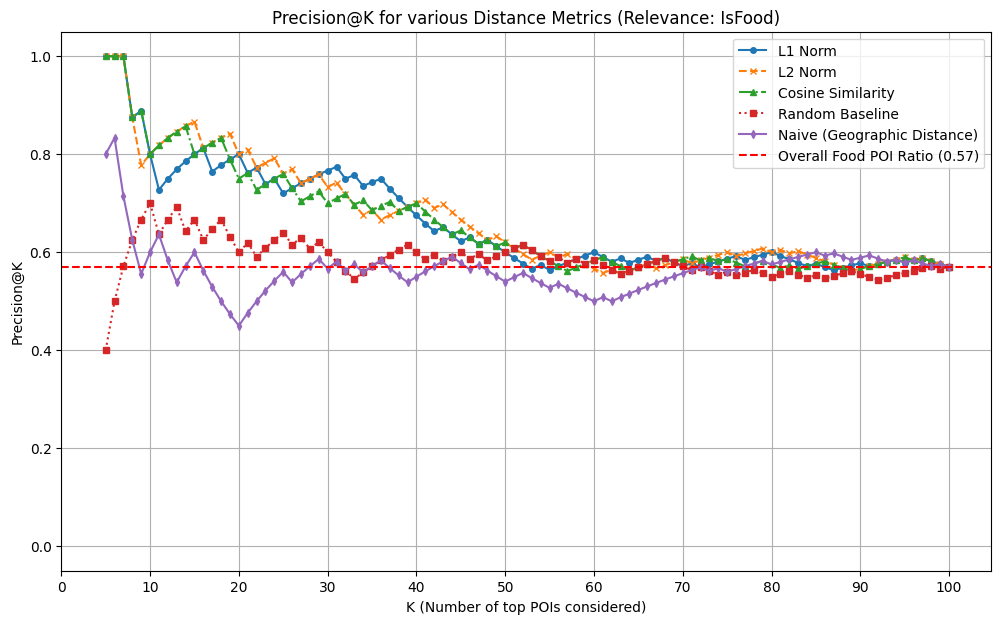


--- Interpretation of Results ---
The overall proportion of food-related POIs among the 100 closest to the Eiffel Tower is approximately 0.57.
This is represented by the red dashed line on the plot.

Observations from the plot:
1. Semantic Search (L1, L2, Cosine Similarity): These metrics consistently show higher Precision@K than both the random baseline and the naive geographic distance, especially for smaller K values. This indicates that the embeddings are effective at identifying food-related POIs early in their ranked lists, given the query 'I want something to eat'.
2. Performance at Small K: For very small K (e.g., K=5 or K=10), the semantic metrics (L1, L2, CS) tend to have similar and high precision, suggesting they are good at finding the most relevant items quickly.
3. Comparison of Semantic Metrics: L1, L2, and Cosine Similarity exhibit very similar performance profiles, indicating that for this dataset and model, the choice among these three might not drastically change t

In [59]:
k_values = list(range(5, 101))

precision_L1 = []
precision_L2 = []
precision_CS = []
precision_random = []
precision_naive = []

for k in k_values:
  # Sort by each metric and take the top K to calculate Precision@K

  # L1 Norm (lower value is better)
  ranked_L1 = eiffel_closest_pois.sort_values('dist_L1', ascending=True).head(k)
  precision_L1.append(ranked_L1['IsFood'].mean())

  # L2 Norm (lower value is better)
  ranked_L2 = eiffel_closest_pois.sort_values('dist_L2', ascending=True).head(k)
  precision_L2.append(ranked_L2['IsFood'].mean())

  # Cosine Similarity (higher value is better/more similar)
  ranked_CS = eiffel_closest_pois.sort_values('dist_CS', ascending=False).head(k)
  precision_CS.append(ranked_CS['IsFood'].mean())

  # Random Baseline: shuffle the dataframe and take top K
  shuffled_pois = eiffel_closest_pois.sample(frac=1, random_state=42).head(k) # Use random_state for reproducibility
  precision_random.append(shuffled_pois['IsFood'].mean())

  # Naive Geographic Distance (lower value is better)
  ranked_naive = eiffel_closest_pois.sort_values('distance_from_eiffel', ascending=True).head(k)
  precision_naive.append(ranked_naive['IsFood'].mean())

# Create a DataFrame for all Precision@K results
precision_df_all_k = pd.DataFrame({
    'K': k_values,
    'Precision_L1': precision_L1,
    'Precision_L2': precision_L2,
    'Precision_CS': precision_CS,
    'Precision_random': precision_random,
    'Precision_naive': precision_naive
})

print(precision_df_all_k.head())

# Plotting Precision@K
plt.figure(figsize=(12, 7))

plt.plot(precision_df_all_k['K'], precision_df_all_k['Precision_L1'], label='L1 Norm', marker='o', markersize=4, linestyle='-')
plt.plot(precision_df_all_k['K'], precision_df_all_k['Precision_L2'], label='L2 Norm', marker='x', markersize=4, linestyle='--')
plt.plot(precision_df_all_k['K'], precision_df_all_k['Precision_CS'], label='Cosine Similarity', marker='^', markersize=4, linestyle='-.')
plt.plot(precision_df_all_k['K'], precision_df_all_k['Precision_random'], label='Random Baseline', marker='s', markersize=4, linestyle=':')
plt.plot(precision_df_all_k['K'], precision_df_all_k['Precision_naive'], label='Naive (Geographic Distance)', marker='d', markersize=4, linestyle='-')

# Add the proportion of food-related places among the 100 closest POIs
food_ratio_100_closest = eiffel_closest_is_food_ratio.loc[True]
plt.axhline(y=food_ratio_100_closest, color='r', linestyle='--', label=f'Overall Food POI Ratio ({food_ratio_100_closest:.2f})')

plt.title('Precision@K for various Distance Metrics (Relevance: IsFood)')
plt.xlabel('K (Number of top POIs considered)')
plt.ylabel('Precision@K')
plt.xticks(np.arange(0, 101, 10)) # Adjust x-axis ticks for better readability
plt.ylim(-0.05, 1.05) # Ensure full range is visible
plt.legend()
plt.grid(True)
plt.show()

# Interpretation and explanation of the results:
print("\n--- Interpretation of Results ---")
print(f"The overall proportion of food-related POIs among the 100 closest to the Eiffel Tower is approximately {food_ratio_100_closest:.2f}.")
print("This is represented by the red dashed line on the plot.")
print("\nObservations from the plot:")
print("1. Semantic Search (L1, L2, Cosine Similarity): These metrics consistently show higher Precision@K than both the random baseline and the naive geographic distance, especially for smaller K values. This indicates that the embeddings are effective at identifying food-related POIs early in their ranked lists, given the query 'I want something to eat'.")
print("2. Performance at Small K: For very small K (e.g., K=5 or K=10), the semantic metrics (L1, L2, CS) tend to have similar and high precision, suggesting they are good at finding the most relevant items quickly.")
print("3. Comparison of Semantic Metrics: L1, L2, and Cosine Similarity exhibit very similar performance profiles, indicating that for this dataset and model, the choice among these three might not drastically change the outcome. All three generally perform well.")
print("4. Naive Geographic Distance: The naive distance also performs reasonably well, outperforming the random baseline. This makes sense because food establishments are often clustered, and the query implicitly asks for food nearby. However, its precision curve generally lies below the semantic metrics for smaller K, meaning it is less effective at *semantically* matching the query than the embedding-based approaches.")
print("5. Random Baseline: As expected, the random baseline shows the lowest precision, fluctuating around the overall food POI ratio as K increases. This confirms that the other methods are indeed performing better than chance.")
print("6. Convergence: As K approaches 100, all precision curves tend to converge towards the overall food POI ratio (around 0.57). This is because when K is large enough to include a significant portion or all of the dataset, the precision will naturally approach the dataset's base rate of relevant items.")
print("\nConclusion: The embedding-based distance metrics (L1, L2, Cosine Similarity) are superior to both the random baseline and the naive geographic distance for finding food-related POIs given a semantic query, particularly when looking for a small number of top results (small K). This demonstrates the effectiveness of the `multilingual-e5-large` model embeddings for geo-semantic search.")

## Q13

#### Identify the distance metric that achieves the highest **Precision@K** for $K<10$.

In [60]:
k_less_than_10_df = precision_df_all_k[precision_df_all_k['K'] < 10]

metrics_to_compare = ['Precision_L1', 'Precision_L2', 'Precision_CS', 'Precision_random', 'Precision_naive']

print("Precision@K for K < 10:")
print(k_less_than_10_df[['K'] + metrics_to_compare].to_string(index=False))

print("\nIdentifying the highest Precision@K for K < 10:")
overall_best_metrics_counts = {}

for index, row in k_less_than_10_df.iterrows():
    k_val = row['K']
    precisions = row[metrics_to_compare]
    max_precision = precisions.max()
    # Find all metrics that achieved this max precision for the current K
    best_metrics_for_k = precisions[precisions == max_precision].index.tolist()

    for metric in best_metrics_for_k:
        overall_best_metrics_counts[metric] = overall_best_metrics_counts.get(metric, 0) + 1

if overall_best_metrics_counts:
    max_frequency = 0
    for freq in overall_best_metrics_counts.values():
        if freq > max_frequency:
            max_frequency = freq

    truly_best_metrics = [metric for metric, freq in overall_best_metrics_counts.items() if freq == max_frequency]

    if len(truly_best_metrics) > 1:
        print(f"Multiple distance metrics consistently achieve the highest Precision@K for K < 10: {', '.join([metric.replace('Precision_', '') for metric in truly_best_metrics])}")
    else:
        print(f"The distance metric that most frequently achieves the highest Precision@K for K < 10 is: {truly_best_metrics[0].replace('Precision_', '')}")
else:
    print("No data available for K < 10.")

Precision@K for K < 10:
 K  Precision_L1  Precision_L2  Precision_CS  Precision_random  Precision_naive
 5      1.000000      1.000000      1.000000          0.400000         0.800000
 6      1.000000      1.000000      1.000000          0.500000         0.833333
 7      1.000000      1.000000      1.000000          0.571429         0.714286
 8      0.875000      0.875000      0.875000          0.625000         0.625000
 9      0.888889      0.777778      0.888889          0.666667         0.555556

Identifying the highest Precision@K for K < 10:
Multiple distance metrics consistently achieve the highest Precision@K for K < 10: L1, CS


## Q14

#### Visualize the top 10 results according to the metric selected in Q13 on a Folium map, displayed alongside the Eiffel Tower.

In [62]:
# Select the top 10 POIs based on L1 Norm (ascending, as it's a distance)
top_10_L1 = eiffel_closest_pois.sort_values('dist_L1', ascending=True).head(10)

# Create a Folium map centered at the Eiffel Tower
top_10_map = folium.Map(location=[eiffel_y, eiffel_x], zoom_start=15, width=1500, height=800)

# Add a marker for the Eiffel Tower
folium.Marker([eiffel_y, eiffel_x], popup="Tour Eiffel", tooltip="Tour Eiffel", icon=folium.Icon(color='red')).add_to(top_10_map)

# Add markers for the top 10 POIs
for idx, row in top_10_L1.iterrows():
    poi_wgs84 = gpd.GeoSeries([row['geometry']], crs=WGS84_UTM_31N).to_crs(WGS84_GEO_DD).iloc[0]
    lat, lon = poi_wgs84.centroid.y, poi_wgs84.centroid.x
    name = row['name']
    is_food = "Food" if row['IsFood'] else "Other"
    folium.Marker(
        [lat, lon],
        popup=f"<b>{name}</b><br>Type: {row['place_type']}<br>Food: {is_food}",
        tooltip=name,
        icon=folium.Icon(color='green' if row['IsFood'] else 'blue')
    ).add_to(top_10_map)

top_10_map

## Q - Bonus

#### Compute **Precision@K** for $K=10$ among the 100 closest points of interest (POIs) to the Eiffel Tower using the L2 norm.

#### Perform this evaluation using text embeddings generated from the following language models:

- [google-bert/bert-base-uncased](https://huggingface.co/google-bert/bert-base-uncased)

- [almanach/camembert-large](https://huggingface.co/almanach/camembert-large)

- [intfloat/multilingual-e5-large](https://huggingface.co/intfloat/multilingual-e5-large)

#### Analyze and interpret the results, highlighting differences in performance across the models.

# Bon appétit!

Create by Etzion Harari | Geo-AI Course | [https://github.com/EtzionR/LM4GeoAI](https://github.com/EtzionR/LM4GeoAI)